<a href="https://colab.research.google.com/github/GabrielaTranslite/Sentiment_Analysis_Video_Games/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

In [3]:
# Reading the reviews file

print(f"Rozmiar pliku: {os.path.getsize('steam_reviews_3274580.csv') / 1024:.0f} KB")

reviews = pd.read_csv('steam_reviews_3274580.csv', on_bad_lines='skip')
print(f"Wierszy: {len(reviews)}")


Rozmiar pliku: 2356 KB
Wierszy: 5268


In [4]:
# Number of reviews
print(f"Reviews before filtering: {len(reviews)}")

Reviews before filtering: 5268


In [5]:
reviews.head()

,review_id,appid,author_steamid,voted_up,votes_up,votes_funny,review_text,timestamp_created,publish_date,hours_on_record,weighted_vote_score,comment_count
0,227214755,3274580,76561198126302244,True,0,0,ok,1780643526,2026-06-05,512.93,0.50000,0
1,227173990,3274580,76561198069792288,True,0,0,I don't understand people. Of course if Ubisof...,1780595391,2026-06-04,59.97,0.50000,0
2,227077952,3274580,76561198389635009,True,0,0,Awesome game! I am looking forward to future c...,1780484019,2026-06-03,4.37,0.50000,0
3,227046650,3274580,76561198060971315,True,1,0,I know this game has been getting mixed review...,1780438119,2026-06-02,33.47,0.52381,0
4,227036499,3274580,76561198032581809,False,6,1,The game seems to just randomly give your city...,1780428223,2026-06-02,23.02,0.57529,0


In [6]:
# Removing empty reviews
reviews = reviews[reviews['review_text'].str.strip() != '']

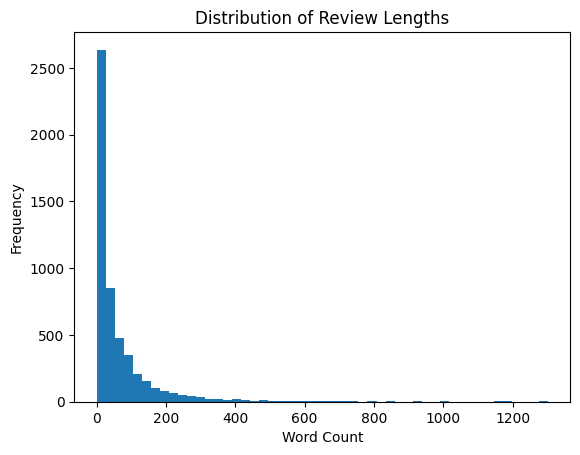

In [7]:
# Review lengths
reviews['word_count'] = reviews['review_text'].str.split().str.len()
plt.hist(reviews['word_count'], bins=50)
plt.title('Distribution of Review Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

In [8]:
# Removing reviews shorter than 3 words
reviews = reviews[reviews['word_count'] >= 3]

In [9]:
print(f"Reviews after filtering: {len(reviews)}")

Reviews after filtering: 4691


In [10]:
# Checking for review_id duplicates in the dataset
reviews.duplicated(subset=['review_id']).sum()

# No duplicates found

np.int64(0)

In [11]:
# Converting columns
reviews['publish_date'] = pd.to_datetime(reviews['publish_date'])
reviews['voted_up'] = reviews['voted_up'].astype(int) # Changing True/False > 1/0
reviews.info()


<class 'pandas.DataFrame'>
Index: 4691 entries, 1 to 5267
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   review_id            4691 non-null   int64         
 1   appid                4691 non-null   int64         
 2   author_steamid       4691 non-null   int64         
 3   voted_up             4691 non-null   int64         
 4   votes_up             4691 non-null   int64         
 5   votes_funny          4691 non-null   int64         
 6   review_text          4691 non-null   str           
 7   timestamp_created    4691 non-null   int64         
 8   publish_date         4691 non-null   datetime64[us]
 9   hours_on_record      4691 non-null   float64       
 10  weighted_vote_score  4691 non-null   float64       
 11  comment_count        4691 non-null   int64         
 12  word_count           4691 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(8), str(1

In [12]:
# Checking the min publish dates
reviews['publish_date'].min()

# The first review was published on 2025-11-12, that is on the realese date of the game, so there are no reviews published before the release date.

Timestamp('2025-11-12 00:00:00')

In [13]:
# Distribution of positive and negative reviews
print(reviews['voted_up'].value_counts(normalize=True))

# The dataset is imbalanced, with 63% positive reviews and 37% negative reviews. 
# This may affect the performance of the reference model (logistic regression), so I will need to use techniques to handle the imbalance, such as oversampling the minority class or using class weights in the model.

voted_up
1    0.626306
0    0.373694
Name: proportion, dtype: float64


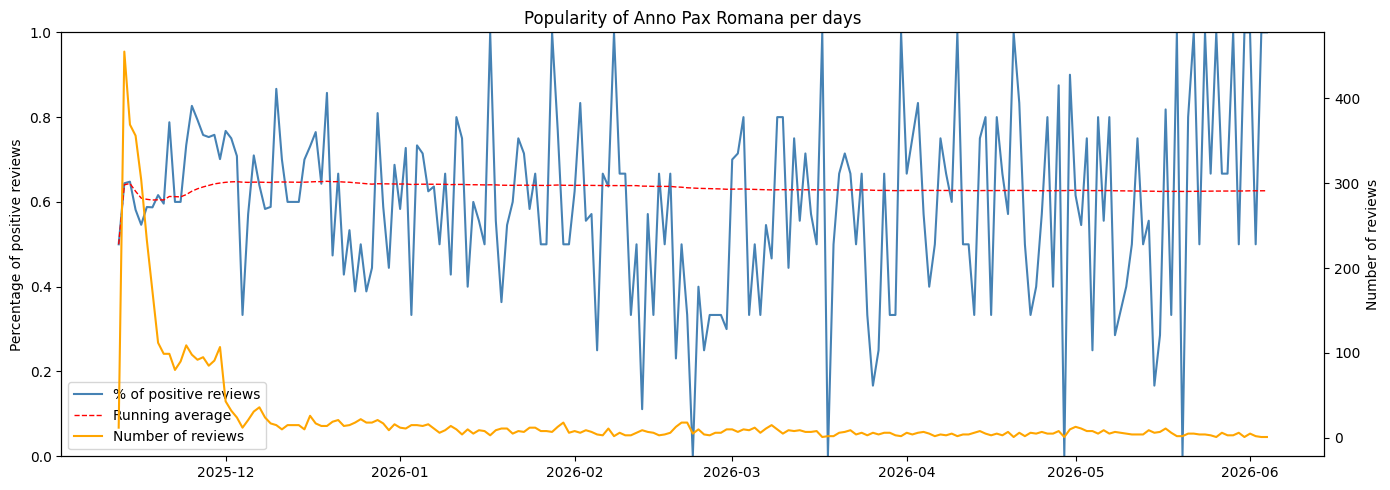

In [14]:
# Score mean and number of reviews per day
daily = reviews.groupby(reviews['publish_date']).agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
).reset_index()

# Running (cumulative) average up to each date
daily['running_avg'] = (
    (daily['avg_score'] * daily['review_count']).cumsum()
    / daily['review_count'].cumsum()
)

# Diagram
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily['publish_date'],
         daily['avg_score'],
         color = 'steelblue',
         label = '% of positive reviews')
ax1.set_ylabel('Percentage of positive reviews')
ax1.set_ylim(0,1)

ax2 = ax1.twinx()
ax2.plot(daily['publish_date'],
         daily['review_count'],
         color = 'orange',
         label = 'Number of reviews')
ax2.set_ylabel('Number of reviews')

# Running average line
ax1.plot(daily['publish_date'],
         daily['running_avg'],
         color='red', linestyle='--', linewidth=1,
         label='Running average')

# Combine legends from both axes into one box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title('Popularity of Anno Pax Romana per days')
fig.tight_layout()
plt.show()


*A simpler chart with patch releases dates*

In [15]:
patch_dates = pd.read_csv('anno_117_pax_romana_patches.csv')
patch_dates.head(18)

,Date,Version,Type,Title,Description
0,2025-11-13,1.2,Game Launch,Anno 117: Pax Romana - Launch Day,Game released on PC / PS5 / Xbox Series X|S. V...
1,2025-11-18,1.2 Hotfix,Hotfix,Multiplayer Hotfix,Hotfix released on PC to fix several causes fo...
2,2025-12-09,1.3 (notes),Patch Notes,Patch 1.3 Notes Published,Official patch notes for version 1.3 published...
3,2025-12-16,1.3,Patch,Patch 1.3 Release,Fixed several crashes and performance issues. ...
4,2026-01-28,1.3.2 (notes),Patch Notes,Patch 1.3.2 Notes Published,Official patch notes for version 1.3.2 publish...
5,2026-01-29,1.3.2,Patch,Patch 1.3.2 Release,Fixes for crashes and the global deity buff. B...
6,2026-02-18,1.4 (notes),Patch Notes,Patch 1.4 Notes Published,Full patch notes for version 1.4 published
7,2026-02-19,1.4,Patch + CDLC,Patch 1.4 + Marvellous Mosaic Pack (Cosmetic DLC),Patch 1.4 adds support for the Marvellous Mosa...
8,2026-03-04,1.4.1,Patch,Patch 1.4.1 Release,Addresses an issue with raytracing on consoles...
9,2026-04-22,NaN,Announcement,Release Delay Announced,DLC Prophecies of Ash and Patch 1.5 delayed by...


In [58]:
# Converting patch release dates to datetime
patch_dates['Date'] = pd.to_datetime(patch_dates['Date'])

# Dropping the rows with patch notes publication dates, as they are not relevant for the analysis
patch_dates = patch_dates[~patch_dates['Title'].str.contains('notes', case=False)]
patch_dates.head(18)

,Date,Version,Type,Title,Description
0,2025-11-13,1.2,Game Launch,Anno 117: Pax Romana - Launch Day,Game released on PC / PS5 / Xbox Series X|S. V...
1,2025-11-18,1.2 Hotfix,Hotfix,Multiplayer Hotfix,Hotfix released on PC to fix several causes fo...
3,2025-12-16,1.3,Patch,Patch 1.3 Release,Fixed several crashes and performance issues. ...
5,2026-01-29,1.3.2,Patch,Patch 1.3.2 Release,Fixes for crashes and the global deity buff. B...
7,2026-02-19,1.4,Patch + CDLC,Patch 1.4 + Marvellous Mosaic Pack (Cosmetic DLC),Patch 1.4 adds support for the Marvellous Mosa...
8,2026-03-04,1.4.1,Patch,Patch 1.4.1 Release,Addresses an issue with raytracing on consoles...
9,2026-04-22,NaN,Announcement,Release Delay Announced,DLC Prophecies of Ash and Patch 1.5 delayed by...
11,2026-04-30,1.5,Major Patch + DLC,Patch 1.5 + Prophecies of Ash DLC,First paid DLC for Anno 117: Pax Romana. Adds ...
12,2026-05-01,1.5 Hotfix,Hotfix,Update 1.5 HotFix (PC),PC hotfix released fixing a crash for campaign...
13,2026-05-05,NaN,Announcement,Upcoming Patches - Message from Anno Team,Team acknowledged issues with Update 1.5 launc...


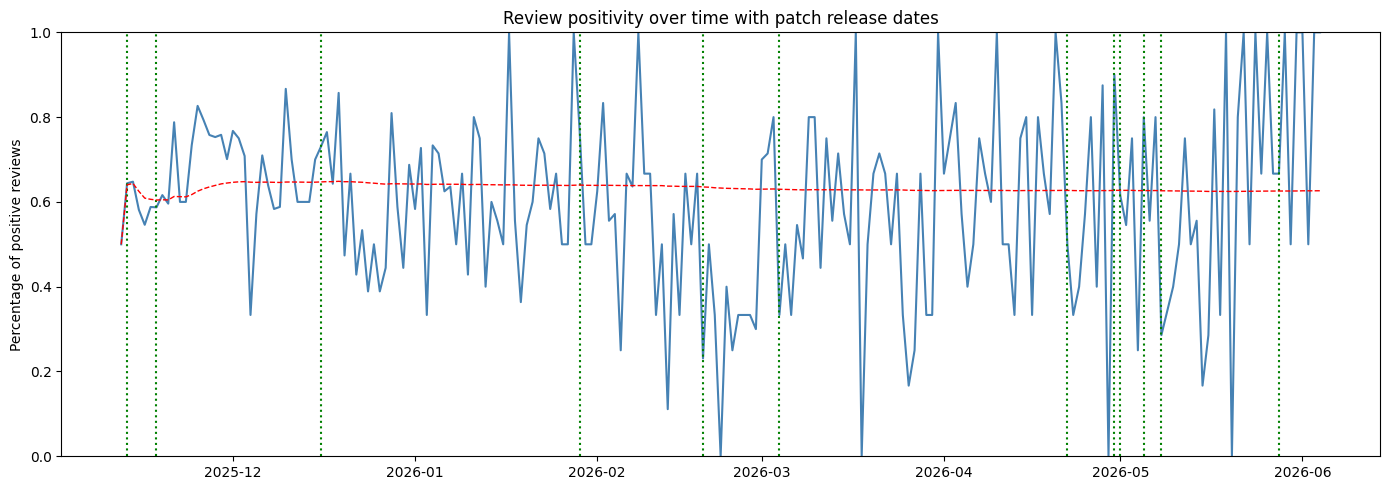

In [ ]:
# Score mean and number of reviews in the periods between patch releases and announcements
releases = reviews.groupby(reviews['publish_date']).agg(
    avg_score = ('voted_up', 'mean'),
    review_count = ('voted_up', 'count')
).reset_index()

# Running (cumulative) average up to each date
daily['running_avg'] = (
    (daily['avg_score'] * daily['review_count']).cumsum()
    / daily['review_count'].cumsum()
)

# Chart with patch release dates
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily['publish_date'],
         daily['avg_score'],
         color = 'steelblue',
         label = '% of positive reviews')
ax1.set_ylabel('Percentage of positive reviews')
ax1.set_ylim(0,1)

# Adding vertical lines for patch release dates
plt.vlines(patch_dates['Date'], ymin=0, ymax=1, color='green', linestyle=':', label='Patch release')


# Running average line
ax1.plot(daily['publish_date'],
         daily['running_avg'],
         color='red', linestyle='--', linewidth=1,
         label='Running average')

# Adding legend for the lines
...
 

plt.title('Review positivity over time with patch release dates')
fig.tight_layout()
plt.show()

In [20]:
# Adding specific periods between patch releases and announcements to table
reviews['period'] = reviews.apply(lambda row:
    '1.2' if row['publish_date'] < pd.Timestamp('2025-11-18') else
    '1.2 Hotfix' if row['publish_date'] < pd.Timestamp('2025-12-16') else
    '1.3' if row['publish_date'] < pd.Timestamp('2026-01-29') and row['publish_date'] >= pd.Timestamp('2025-12-16') else
    '1.3.2' if row['publish_date'] < pd.Timestamp('2026-02-19') and row['publish_date'] >= pd.Timestamp('2026-01-29') else
    '1.4 + Cosmetic DLC' if row['publish_date'] < pd.Timestamp('2026-03-04') and row['publish_date'] >= pd.Timestamp('2026-02-19') else
    '1.4.1' if row['publish_date'] < pd.Timestamp('2026-04-22') and row['publish_date'] >= pd.Timestamp('2026-03-04') else
    'Release Delay Announced' if row['publish_date'] < pd.Timestamp('2026-04-30') else
    '1.5 + Paid DLC + Hotfix' if row['publish_date'] < pd.Timestamp('2026-04-30') and row['publish_date'] >= pd.Timestamp('2026-04-22') else
    '1.5.1' if row['publish_date'] < pd.Timestamp('2026-05-08') and row['publish_date'] >= pd.Timestamp('2026-04-30') else
    '1.5.2', axis=1)

reviews.tail()

,review_id,appid,author_steamid,voted_up,votes_up,votes_funny,review_text,timestamp_created,publish_date,hours_on_record,weighted_vote_score,comment_count,word_count,period
5262,209074228,3274580,76561197960711140,1,0,0,Basically poops on the likes of Europa 5 Can't...,1762990994,2025-11-12,0.48,0.469799,0,19.0,1.2
5263,209074198,3274580,76561198041549155,0,0,0,Performance has improved slightly after the Da...,1762990969,2025-11-12,8.00,0.500000,0,166.0,1.2
5264,209074064,3274580,76561198144246893,0,0,0,"Mediocre graphics, art, UI compared to anno 18...",1762990841,2025-11-12,3.73,0.500000,0,69.0,1.2
5266,209072424,3274580,76561199492495065,1,0,0,"Make sure to update nVidia drivers to latest, ...",1762989478,2025-11-12,7.50,0.417803,2,152.0,1.2
5267,209072379,3274580,76561197972252273,1,0,0,GOTY Downsides: - The UI is a lot worse than ...,1762989440,2025-11-12,6.48,0.500000,0,69.0,1.2


## Sentiment Analysis using VADER algorithm

In [33]:
# Definying a cleaning function before analysis

def clean_text(text):
    text = text.lower()                          # small leters
    text = re.sub(r'http\S+', '', text)          # removing links
    text = re.sub(r'[^\w\s]', '', text)          # removing punctuation
    text = re.sub(r'\s+', ' ', text).strip()     # removing multiple spaces
    return text

reviews['clean_text'] = reviews['review_text'].apply(clean_text)

In [34]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
reviews['sentiment_score'] = reviews['clean_text'].apply(
    lambda x: sia.polarity_scores(x)['compound']  # range from -1 to +1
)

# Conversion to binary
reviews['sentiment_label'] = reviews['sentiment_score'].apply(
    lambda x: 1 if x >= 0.05 else 0
)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [35]:
# Checking the results with a classification report

from sklearn.metrics import classification_report

print(classification_report(
    reviews['voted_up'].astype(int),
    reviews['sentiment_label']
))

              precision    recall  f1-score   support

           0       0.68      0.51      0.59      1753
           1       0.75      0.86      0.80      2938

    accuracy                           0.73      4691
   macro avg       0.72      0.69      0.69      4691
weighted avg       0.72      0.73      0.72      4691



Both the classification report and the chart above show that VADER algorithm had some problems with distinguishing the correct sentiment. It's particularly visible in the "positive" peaks in March, April and May of 2026, where we have days with only negative scores from Steam. However, by the end of May, we can also see days where the VADER algorithm have incorrectly classified some positive reviews as negative reviews. The overal score is quite good with accuracy of 73%.

## Lemmatization
Now, I am going to lemmatize the dataset in order to check whether this approach will improve the scores.

In [ ]:
from nltk.stem import WordNetLemmatizer
wordnet_lemmatizer = WordNetLemmatizer()
nltk.download('wordnet')
reviews['lemmatized_text'] = reviews['clean_text'].apply(
    lambda x: ' '.join(wordnet_lemmatizer.lemmatize(word) for word in x.split())
)

sia_lemmatized = SentimentIntensityAnalyzer()
reviews['sentiment_score_lemmatized'] = reviews['lemmatized_text'].apply(
    lambda x: sia_lemmatized.polarity_scores(x)['compound']  # range from -1 to +1
)

# Conversion to binary
reviews['sentiment_label_lemmatized'] = reviews['sentiment_score_lemmatized'].apply(
    lambda x: 1 if x >= 0.05 else 0
)

print(classification_report(
    reviews['voted_up'].astype(int),
    reviews['sentiment_label_lemmatized']
))

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gabri\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


              precision    recall  f1-score   support

           0       0.69      0.50      0.58      1753
           1       0.74      0.86      0.80      2938

    accuracy                           0.73      4691
   macro avg       0.71      0.68      0.69      4691
weighted avg       0.72      0.73      0.72      4691



### Analysis of several incorrectly marked reviews

In [80]:
# Analyzing a sample of incorrectly classified reviews
incorrect = reviews[reviews['voted_up'].astype(int) != reviews['sentiment_label']]
print(incorrect[['review_text', 'voted_up', 'sentiment_label']].sample(10, random_state=42))

                                            review_text  voted_up  \
5054  Solo player game only. tried with friends for ...         0   
3439  I'm not going to lie, this game is, overall, d...         0   
1826  Ich spiele ANNO bereits seit 1602. Aber Pax Ro...         1   
5246  This is a mixed bag... but I'm a sucker for a ...         1   
4099  I’m very disappointed that AI was used in the ...         0   
4067  Sadly, the game is super underwhelming with li...         0   
104   Compared to Anno 1800, this is a huge step bac...         0   
1749  AI generated graphics. Poorly written narrativ...         0   
190   I really wanted to like this game but the Ubis...         0   
2602  Roman/Celtic sim city with some factorio and T...         1   

      sentiment_label  
5054                1  
3439                1  
1826                0  
5246                0  
4099                1  
4067                1  
104                 1  
1749                1  
190                 1  


In [85]:
pd.set_option('display.max_colwidth', None)
print(incorrect[['review_text', 'voted_up', 'sentiment_label']].sample(10, random_state=42))


In [76]:
# TF-IDF Analysis
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(stop_words="english", max_features=5000)
X = vec.fit_transform(reviews['clean_text'])

# Creating masks for positive and negative reviews (.values → numpy array, required for sparse indexing)
pos_mask = (reviews['voted_up'] == 1).values
neg_mask = (reviews['voted_up'] == 0).values

# Mean TF-IDF scores for each term in positive and negative reviews
mean_pos = np.asarray(X[pos_mask].mean(axis=0)).flatten()
mean_neg = np.asarray(X[neg_mask].mean(axis=0)).flatten()

terms = vec.get_feature_names_out()

# Top terms characteristic for positive reviews
top_pos = sorted(zip(terms, mean_pos), key=lambda x: x[1], reverse=True)[:20]
print("Top terms for positive reviews:")
for term, score in top_pos:
    print(f"{term}: {score}")




Top terms for positive reviews:
game: 0.07646745246221762
anno: 0.07005038538779115
good: 0.04590177108887076
great: 0.044792007571184164
1800: 0.03679240646429306
like: 0.03541689980442225
fun: 0.03021387598729974
love: 0.02609045644120936
city: 0.023834503157895186
far: 0.022571886189362064
really: 0.02139916506473474
new: 0.021100430311736064
just: 0.02103828440842731
best: 0.019863631622805352
time: 0.01873376233607884
im: 0.01790390768748206
play: 0.017202030986519404
series: 0.01657369631699002
games: 0.016179795721089168
campaign: 0.01612742322223804


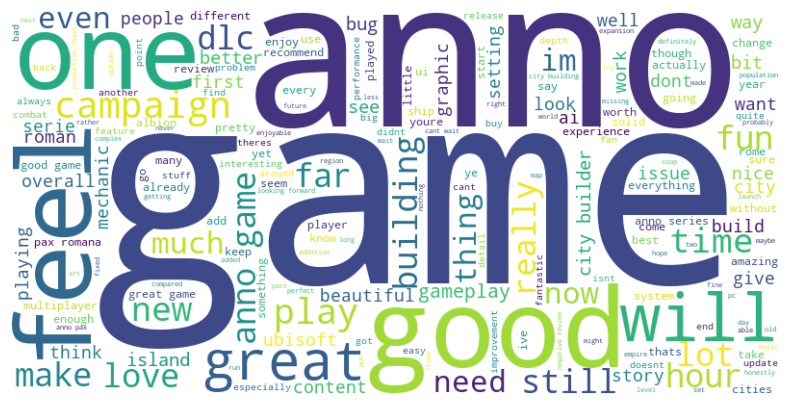

In [77]:
# Generating a WordCloud for positive reviews

from wordcloud import WordCloud
positive_text = ' '.join(reviews[reviews['voted_up'] == 1]['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [78]:
# Top terms characteristic for negative reviews
top_neg = sorted(zip(terms, mean_neg), key=lambda x: x[1], reverse=True)[:20]
print("\nTop terms for negative reviews:")
for term, score in top_neg:
    print(f"{term}: {score}")


Top terms for negative reviews:
game: 0.07387735370552487
ubisoft: 0.03585935221118436
anno: 0.03561057980821237
just: 0.035073474546106466
1800: 0.03253589045507964
like: 0.029273338401580397
ai: 0.02772325984097026
multiplayer: 0.026363389678513063
campaign: 0.02588874840981085
play: 0.024710414730911196
dont: 0.020860243641606133
feels: 0.01921738672782831
time: 0.016307705775910942
really: 0.016206512880092883
bad: 0.015208846820818881
games: 0.014985968186869324
good: 0.014788110303400439
hours: 0.014768617664231102
buy: 0.014672467572994743
better: 0.014352087689000596


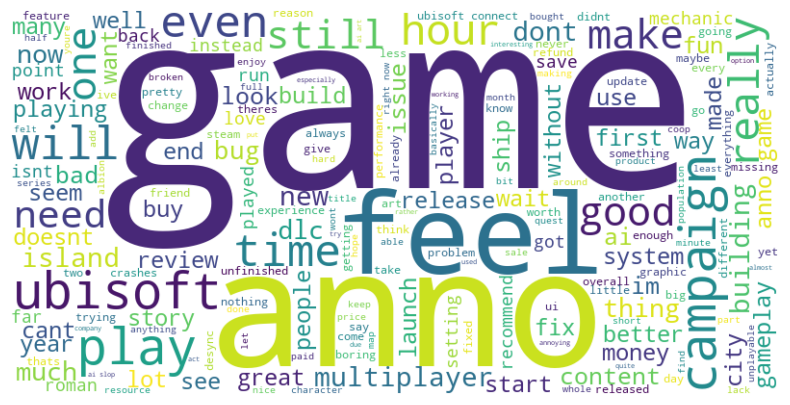

In [79]:
# Generating word clouds for negative reviews
negative_text = ' '.join(reviews[reviews['voted_up'] == 0]['clean_text'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.show()

## Analyzing key phrases in negative reviews using KeyBERT algorithm

In [69]:
# Analyzing key phrases in negative reviews using KeyBERT
!pip install keybert -q
from keybert import KeyBERT

kw_model = KeyBERT()

# Joining all negative reviews into one text for key phrase extraction
neg_text = " ".join(reviews[reviews['voted_up'] == 0]['clean_text'].dropna().tolist())

keywords = kw_model.extract_keywords(
    neg_text,
    keyphrase_ngram_range=(2, 4),
    stop_words="english",
    top_n=40
)
for phrase, score in keywords:
    print(f"{score:.3f}  {phrase}")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\gabri\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

0.690  game ubisoft connect bad
0.689  game ubisoft connect suck
0.682  game suffers heavily ubisoft
0.681  worst game ubisoft connect
0.680  ubisoft games failing
0.677  game hate ubisoft connect
0.676  ubisoft connect terrible terrible
0.676  ubisoft connect really bad
0.671  ubisoft connect horrible
0.670  ubisoft connect terrible
0.670  good ubisoft connect terrible
0.669  ubisoft connect sucks
0.666  ubisoft bad
0.666  ubisofts infrastructure notoriously flaky
0.665  unreliable ubisoft games
0.662  ubisoft connect ruined game
0.662  issues ubisoft
0.660  ubisoft game disappointing
0.658  game ubisoft dont good
0.654  ubisoft sucks
0.654  issues secondly ubisoft
0.654  game sucks ubisoft
0.653  ubisoft connect bad
0.652  turn ubisoft decent city
0.652  trough steam terrible ubisoft
0.652  coming ubisoft game disappointing
0.652  game ubisoft fixes
0.652  steam terrible ubisoft
0.650  issues seeing ubisoft
0.650  issues seeing ubisoft doing
0.650  launching ubisoft needs fix
0.649  

In [73]:
# LDA topic modeling on all reviews

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vec = CountVectorizer(ngram_range=(1, 1), stop_words="english",
                      max_features=3000, min_df=10)
X = vec.fit_transform(reviews['clean_text'].dropna())

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

feature_names = vec.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [feature_names[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: game, 1800, anno, just, like, dlc, new, campaign, content, good
Topics 2: game, campaign, like, just, anno, feels, performance, hours, story, settings
Topics 3: anno, game, 1800, like, city, great, really, new, roman, good
Topics 4: game, ai, like, dont, art, just, ubisoft, anno, people, im
Topics 5: game, ubisoft, multiplayer, play, good, bugs, anno, issues, connect, time


In [74]:
# LDA topic modeling on positive reviews

vec_pos = CountVectorizer(ngram_range=(1, 1), stop_words="english", max_features=3000, min_df=10)
X_pos = vec_pos.fit_transform(reviews[reviews['voted_up'] == 1]['clean_text'].dropna())
lda_pos = LatentDirichletAllocation(n_components=5, random_state=42)
lda_pos.fit(X_pos) 
feature_names_pos = vec_pos.get_feature_names_out()
for i, topic in enumerate(lda_pos.components_):
    top_words = [feature_names_pos[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: anno, game, 1800, great, new, campaign, like, 117, series, good
Topics 2: city, game, roman, anno, builder, pax, romana, building, empire, 117
Topics 3: game, like, just, anno, really, 1800, building, buildings, production, build
Topics 4: game, good, just, ubisoft, play, like, im, dont, great, ai
Topics 5: anno, game, 1800, good, like, love, far, fun, better, best


In [75]:
# LDA topic modeling on negative reviews
vec_neg = CountVectorizer(ngram_range=(1, 1), stop_words="english", max_features=3000, min_df=10)
X_neg = vec_neg.fit_transform(reviews[reviews['voted_up'] == 0]['clean_text'].dropna())
lda_neg = LatentDirichletAllocation(n_components=5, random_state=42)
lda_neg.fit(X_neg)
feature_names_neg = vec_neg.get_feature_names_out()
for i, topic in enumerate(lda_neg.components_):
    top_words = [feature_names_neg[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topics {i+1}: {', '.join(top_words)}")

Topics 1: game, ubisoft, dlc, pass, year, release, content, paid, buy, edition
Topics 2: ai, game, anno, art, 1800, ubisoft, like, dont, slop, campaign
Topics 3: game, ubisoft, play, multiplayer, just, time, connect, hours, issues, work
Topics 4: game, anno, build, need, city, like, time, fps, settings, trade
Topics 5: game, anno, 1800, like, just, campaign, feels, really, new, feel
